# xView2 Baseline


This notebook documents the *full pipeline* required to run the xView2 baseline on a modern machine (macOS, Apple Silicon)

---

## Core Principle

- Model execution runs **ONLY** inside Docker
- Notebook is used for:
  - Control
  - Evaluation
  - Visualization

---

## Required Installations

**Download:**


- ```test``` 
- ```train``` 

**From:**

https://xview2.org/download-links


**Place in:**

```
Desktop
```

---

**Download:**

```
classification.hdf5
```

**From:**

https://github.com/DIUx-xView/xView2_baseline/releases/tag/v1.0

**Place in:**

```
weights/
```
---


## Required External Apps


- ```docker```
- ```miniconda```

---

### a. Create Environment

Miniconda was used to manage the Python environment for the notebook.

```bash
conda create -n xview2 python=3.8
conda activate xview2
```

---

### b. Install Notebook Dependencies

```bash
pip install numpy pandas matplotlib scikit-learn shapely pillow jupyter ipykernel
```

**Register kernel:**

```bash
python -m ipykernel install --user --name xview2 --display-name "Python (xview2)"
```

**Install aditional packages:**

!!!!!!!ADD PACKAGES THAT ARE NOT INCLUDED IN DOCKER ENVIRONMENT

---

### c. Install Docker

**Verify:**

```bash
docker --version
```

> ⚠️ On Mac (Apple Silicon), ALWAYS use:

```bash
--platform linux/amd64
```

---

In [18]:
from pathlib import Path

# Adjust only this if needed
DATA_ROOT = Path.home() / "Desktop" / "train"

IMAGE_DIR = DATA_ROOT / "images"
OUTPUT_DIR = Path.home() / "Desktop" / "output"

# ✅ Create output folder automatically if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Images:", IMAGE_DIR)
print("Output:", OUTPUT_DIR)

Images: /Users/paolo/Desktop/train/images
Output: /Users/paolo/Desktop/output


In [19]:
!docker build --platform linux/amd64 -f submission/Dockerfile -t cmu-xview2-baseline .


[+] Building 0.0s (0/1)                                    docker:desktop-linux
[+] Building 0.2s (1/2)                                    docker:desktop-linux
 => [internal] load build definition from Dockerfile                       0.0s
 => => transferring dockerfile: 3.75kB                                     0.0s
 => [internal] load metadata for docker.io/library/ubuntu:18.04            0.2s
[+] Building 0.3s (1/2)                                    docker:desktop-linux
 => [internal] load build definition from Dockerfile                       0.0s
 => => transferring dockerfile: 3.75kB                                     0.0s
 => [internal] load metadata for docker.io/library/ubuntu:18.04            0.3s
[+] Building 0.5s (1/2)                                    docker:desktop-linux
 => [internal] load build definition from Dockerfile                       0.0s
 => => transferring dockerfile: 3.75kB                                     0.0s
 => [internal] load metadata for docker

In [20]:
import subprocess

cmd = [
    "docker", "run", "--rm", "--platform", "linux/amd64",
    "-v", f"{IMAGE_DIR}:/submission",
    "-v", f"{OUTPUT_DIR}:/output",
    "cmu-xview2-baseline",
    f"/submission/{base}_pre_disaster.png",
    f"/submission/{base}_post_disaster.png",
    f"/output/{base}_loc.png",
    f"/output/{base}_cls.png",
]

subprocess.run(cmd, check=True)

Running localization
Grabbing post image file for classification
Running classification
Formatting json and scoring image
Finalizing output file
Cleaning up
Done!


CompletedProcess(args=['docker', 'run', '--rm', '--platform', 'linux/amd64', '-v', '/Users/paolo/Desktop/train/images:/submission', '-v', '/Users/paolo/Desktop/output:/output', 'cmu-xview2-baseline', '/submission/guatemala-volcano_00000000_pre_disaster.png', '/submission/guatemala-volcano_00000000_post_disaster.png', '/output/guatemala-volcano_00000000_loc.png', '/output/guatemala-volcano_00000000_cls.png'], returncode=0)

In [41]:
from pathlib import Path
import subprocess

image_dir = Path.home() / "Desktop" / "train" / "images"
output_dir = Path.home() / "Desktop" / "output_batch"

pre_files = sorted(image_dir.glob("*_pre_disaster.png"))[500:]

processed = 0
skipped = 0
failed = 0

for idx, pre in enumerate(pre_files, start=1):
    base = pre.name.replace("_pre_disaster.png", "")
    post = image_dir / f"{base}_post_disaster.png"

    if not post.exists():
        print(f"[{idx}] Skipping {base}: missing post image")
        skipped += 1
        continue

    cmd = [
        "docker", "run", "--rm", "--platform", "linux/amd64",
        "-v", f"{image_dir}:/submission",
        "-v", f"{output_dir}:/output",
        "cmu-xview2-baseline",
        f"/submission/{base}_pre_disaster.png",
        f"/submission/{base}_post_disaster.png",
        f"/output/{base}_loc.png",
        f"/output/{base}_cls.png",
    ]

    print(f"[{idx}] Processing {base}")

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print(f"❌ FAILED: {base}")
        print(result.stderr[:500])  # print first part of error
        failed += 1
        continue

    processed += 1

print("\nDone.")
print(f"Processed: {processed}")
print(f"Skipped: {skipped}")
print(f"Failed: {failed}")

[1] Processing hurricane-harvey_00000265
[2] Processing hurricane-harvey_00000266
[3] Processing hurricane-harvey_00000267
[4] Processing hurricane-harvey_00000268
[5] Processing hurricane-harvey_00000269
[6] Processing hurricane-harvey_00000270
[7] Processing hurricane-harvey_00000271
[8] Processing hurricane-harvey_00000272
[9] Processing hurricane-harvey_00000273
[10] Processing hurricane-harvey_00000274
[11] Processing hurricane-harvey_00000275
[12] Processing hurricane-harvey_00000277
[13] Processing hurricane-harvey_00000278
[14] Processing hurricane-harvey_00000280
[15] Processing hurricane-harvey_00000281
[16] Processing hurricane-harvey_00000284
[17] Processing hurricane-harvey_00000285
[18] Processing hurricane-harvey_00000286
[19] Processing hurricane-harvey_00000288
[20] Processing hurricane-harvey_00000289
[21] Processing hurricane-harvey_00000291
[22] Processing hurricane-harvey_00000292
[23] Processing hurricane-harvey_00000299
[24] Processing hurricane-harvey_00000300
[

KeyboardInterrupt: 

In [42]:
!python3 utils/evaluate.py

guatemala-volcano_00000001_loc.json: gt_buildings=4, pred_buildings=4, matched=4
guatemala-volcano_00000002_loc.json: gt_buildings=1, pred_buildings=3, matched=1
guatemala-volcano_00000006_loc.json: gt_buildings=97, pred_buildings=97, matched=70
guatemala-volcano_00000007_loc.json: gt_buildings=9, pred_buildings=10, matched=7
guatemala-volcano_00000008_loc.json: gt_buildings=0, pred_buildings=0, matched=0
guatemala-volcano_00000010_loc.json: gt_buildings=2, pred_buildings=0, matched=0
guatemala-volcano_00000013_loc.json: gt_buildings=13, pred_buildings=16, matched=8
guatemala-volcano_00000015_loc.json: gt_buildings=131, pred_buildings=136, matched=74
guatemala-volcano_00000016_loc.json: gt_buildings=7, pred_buildings=17, matched=3
guatemala-volcano_00000017_loc.json: gt_buildings=58, pred_buildings=48, matched=19
guatemala-volcano_00000018_loc.json: gt_buildings=12, pred_buildings=13, matched=9
guatemala-volcano_00000019_loc.json: gt_buildings=22, pred_buildings=31, matched=11
guatemal

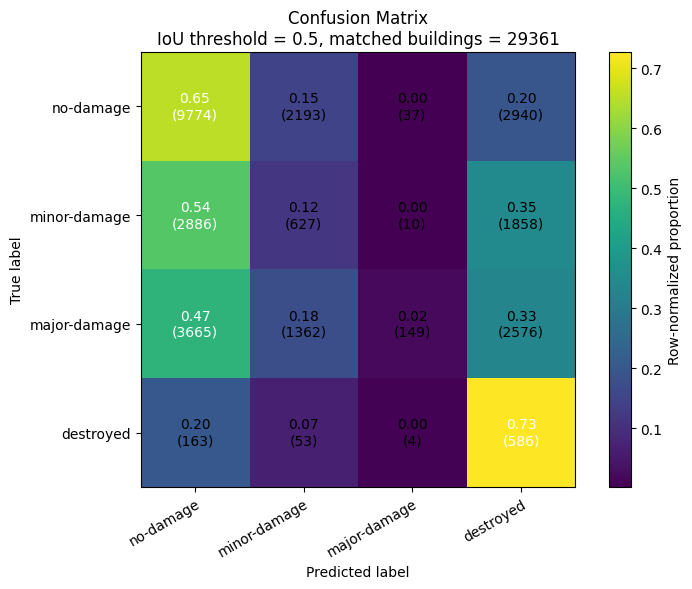

Counts matrix:
[[9774 2193   37 2940]
 [2886  627   10 1858]
 [3665 1362  149 2576]
 [ 163   53    4  586]]


In [43]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from shapely import wkt
from sklearn.metrics import confusion_matrix

# =========================
# CONFIG
# =========================
PROJECT_ROOT = Path.cwd()

# If your notebook is inside the repo root, this is enough.
# Otherwise set PROJECT_ROOT manually, for example:
# PROJECT_ROOT = Path("/Users/paolo/Documents/GitHub/xView2_baseline_thesis")

DATA_ROOT = Path.home() / "Desktop" / "train"
GT_DIR = DATA_ROOT / "labels"
PRED_DIR = Path.home() / "Desktop" / "output_batch"

IOU_THRESHOLD = 0.5
LABELS = ["no-damage", "minor-damage", "major-damage", "destroyed"]

# =========================
# HELPERS
# =========================
def load_features(json_path: Path):
    with open(json_path, "r") as f:
        data = json.load(f)
    return data["features"]["xy"]

def prediction_base_to_gt_base(file_name: str) -> str:
    base = file_name[:-5]  # remove .json
    if base.endswith("_loc"):
        base = base[:-4]
    elif base.endswith("_cls"):
        base = base[:-4]
    return base

def polygon_iou(poly_a, poly_b):
    inter = poly_a.intersection(poly_b).area
    union = poly_a.union(poly_b).area
    if union == 0:
        return 0.0
    return inter / union

def build_polygon_entries(features):
    entries = []
    for item in features:
        props = item.get("properties", {})
        subtype = props.get("subtype")
        poly_wkt = item.get("wkt")

        if subtype is None or poly_wkt is None:
            continue

        try:
            geom = wkt.loads(poly_wkt)
        except Exception:
            continue

        if geom.is_empty:
            continue

        if not geom.is_valid:
            geom = geom.buffer(0)

        if geom.is_empty:
            continue

        entries.append({
            "subtype": subtype,
            "geometry": geom,
        })
    return entries

def match_predictions_to_ground_truth(gt_entries, pred_entries, iou_threshold=0.5):
    y_true = []
    y_pred = []
    used_gt = set()

    for pred in pred_entries:
        best_gt_idx = None
        best_iou = 0.0

        for gt_idx, gt in enumerate(gt_entries):
            if gt_idx in used_gt:
                continue

            iou = polygon_iou(pred["geometry"], gt["geometry"])
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_gt_idx is not None and best_iou >= iou_threshold:
            used_gt.add(best_gt_idx)
            y_true.append(gt_entries[best_gt_idx]["subtype"])
            y_pred.append(pred["subtype"])

    return y_true, y_pred

# =========================
# COLLECT MATCHED LABELS
# =========================
all_y_true = []
all_y_pred = []

pred_files = sorted([p for p in PRED_DIR.iterdir() if p.suffix == ".json"])

if not pred_files:
    raise FileNotFoundError(f"No prediction JSON files found in {PRED_DIR}")

for pred_file in pred_files:
    base = prediction_base_to_gt_base(pred_file.name)
    gt_file = GT_DIR / f"{base}_post_disaster.json"

    if not gt_file.exists():
        print(f"Skipping {pred_file.name}: missing ground truth file {gt_file.name}")
        continue

    gt_features = load_features(gt_file)
    pred_features = load_features(pred_file)

    gt_entries = build_polygon_entries(gt_features)
    pred_entries = build_polygon_entries(pred_features)

    y_true, y_pred = match_predictions_to_ground_truth(
        gt_entries, pred_entries, iou_threshold=IOU_THRESHOLD
    )

    all_y_true.extend(y_true)
    all_y_pred.extend(y_pred)

if not all_y_true:
    raise ValueError("No matched building predictions found. Nothing to plot.")

# =========================
# CONFUSION MATRICES
# =========================
cm_counts = confusion_matrix(all_y_true, all_y_pred, labels=LABELS)

row_sums = cm_counts.sum(axis=1, keepdims=True)
cm_norm = np.divide(
    cm_counts,
    row_sums,
    out=np.zeros_like(cm_counts, dtype=float),
    where=row_sums != 0
)

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_norm, interpolation="nearest")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Row-normalized proportion", rotation=90)

ax.set(
    xticks=np.arange(len(LABELS)),
    yticks=np.arange(len(LABELS)),
    xticklabels=LABELS,
    yticklabels=LABELS,
    xlabel="Predicted label",
    ylabel="True label",
    title=f"Confusion Matrix\nIoU threshold = {IOU_THRESHOLD}, matched buildings = {len(all_y_true)}"
)

plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")

# Overlay normalized values + raw counts
threshold = cm_norm.max() / 2 if cm_norm.max() > 0 else 0.5

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        text_color = "white" if cm_norm[i, j] > threshold else "black"
        ax.text(
            j, i,
            f"{cm_norm[i, j]:.2f}\n({cm_counts[i, j]})",
            ha="center", va="center",
            color=text_color, fontsize=10
        )

fig.tight_layout()
plt.show()

print("Counts matrix:")
print(cm_counts)

/var/folders/bs/rzk6qg1902vgdlp6h22t8bq40000gn/T/ipykernel_31948/2903908980.py:59: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


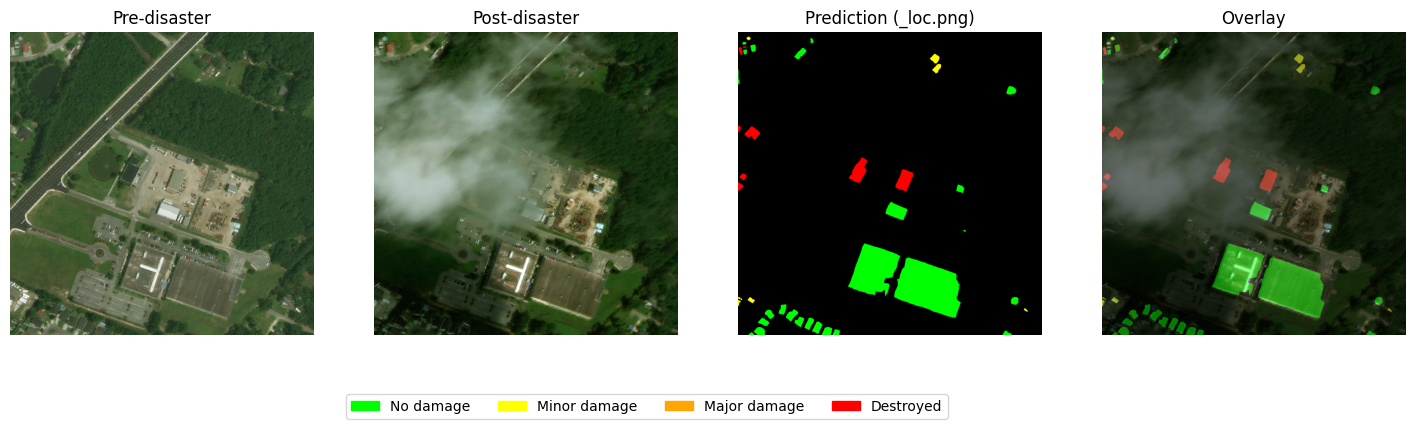

In [40]:

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

DATA_ROOT = Path.home() / "Desktop" / "train"
IMAGE_DIR = DATA_ROOT / "images"
OUTPUT_DIR = Path.home() / "Desktop" / "output_batch"


base = "hurricane-florence_00000012"
pred_suffix = "_loc.png"

pre_path = IMAGE_DIR / f"{base}_pre_disaster.png"
post_path = IMAGE_DIR / f"{base}_post_disaster.png"
pred_path = OUTPUT_DIR / f"{base}{pred_suffix}"

pre = Image.open(pre_path)
post = Image.open(post_path)
pred = Image.open(pred_path)

pre_arr = np.array(pre)
post_arr = np.array(post)
pred_arr = np.array(pred)

legend_elements = [
    mpatches.Patch(color=(0, 1, 0), label="No damage"),
    mpatches.Patch(color=(1, 1, 0), label="Minor damage"),
    mpatches.Patch(color=(1, 0.65, 0), label="Major damage"),
    mpatches.Patch(color=(1, 0, 0), label="Destroyed"),
]

plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(pre_arr)
plt.title("Pre-disaster")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(post_arr)
plt.title("Post-disaster")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pred_arr)
plt.title(f"Prediction ({pred_suffix})")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(post_arr)
plt.imshow(pred_arr, alpha=0.45)
plt.title("Overlay")
plt.axis("off")

plt.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(-1.5, -0.3), ncol=4)

plt.tight_layout()
plt.show()